<a href="https://colab.research.google.com/github/RaheemKProjects/Raheem-North-Star-Analytical-Workflow/blob/main/02_r_analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/[USERNAME]/northstar-analytics-cw1/blob/main/notebooks/02_r_analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 02 — R Analytics: Statistical Modelling and Visualisation

**NorthStar Analytics

ANOVA, correlation analysis, multiple linear regression, and ggplot2 visualisations to quantify the patterns identified in Notebook 01.

In [ ]:
install.packages(c('tidyverse', 'broom', 'corrplot'), quiet = TRUE)
library(tidyverse); library(broom); library(corrplot)
set.seed(42)

In [ ]:
# Load and clean (re-using the function from Notebook 01)
customers  <- read.csv('customers.csv')
orders     <- read.csv('orders.csv')
deliveries <- read.csv('deliveries.csv')
drivers    <- read.csv('drivers.csv')
vehicles   <- read.csv('vehicles.csv')
hubs       <- read.csv('hubs.csv')

normalise_zone <- function(x) {
  x <- toupper(trimws(x))
  x[x %in% c('CTR','CENTRAL')] <- 'Central'
  x[x == 'AIRPORT']            <- 'Airport'
  x[x == 'NORTH']              <- 'North'
  x[x == 'SOUTH']              <- 'South'
  x[x == 'EAST']               <- 'East'
  x[x == 'WEST']               <- 'West'
  x[x == 'RIVERSIDE']          <- 'Riverside'
  return(x)
}
orders$pickup_zone <- normalise_zone(orders$pickup_zone)

master <- orders %>%
  inner_join(deliveries, by = 'order_id') %>%
  left_join(drivers,    by = 'driver_id') %>%
  left_join(vehicles,   by = 'vehicle_id') %>%
  left_join(hubs,       by = 'hub_id')

glimpse(master)

Rows: 950
Columns: 41
$ order_id                      <chr> "O00001", "O00003", "O00004", "O00005", …
$ customer_id                   <chr> "C0292", "C0161", "C0520", "C0558", "C00…
$ service_type                  <chr> "Passenger", "Passenger", "Parcel", "Ret…
$ order_created_at              <chr> "2024-08-20 14:43:00", "2025-09-02 14:37…
$ promised_window_hours         <int> 6, 4, 2, 12, 2, 4, 12, 6, 12, 24, 6, 6, …
$ pickup_zone                   <chr> "Airport", "West", "Riverside", "Riversi…
$ dropoff_zone                  <chr> "South", "AIRPORT", "North", "SOUTH", "A…
$ priority_level                <chr> "Medium", "High", "Medium", "Low", "Low"…
$ order_value                   <dbl> 126.65, 33.50, 10.04, 125.58, 76.12, 35.…
$ booking_channel               <chr> "App", "Phone", "App", "Phone", "App", "…
$ special_handling_flag         <int> 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0…
$ delivery_id                   <chr> "DL00937", "DL00925", "DL00002", "DL0067…
$ driver_id       

## 1. Descriptive statistics

In [ ]:
master %>%
  select(order_value, route_distance_km, fuel_or_charge_cost,
         manual_route_override_count, customer_rating_post_delivery) %>%
  summary()

  order_value     route_distance_km fuel_or_charge_cost
 Min.   :  2.04   Min.   : 1.200    Min.   : 2.500     
 1st Qu.: 48.61   1st Qu.: 9.135    1st Qu.: 9.925     
 Median : 77.17   Median :12.840    Median :12.645     
 Mean   : 91.86   Mean   :13.909    Mean   :12.841     
 3rd Qu.:122.82   3rd Qu.:16.835    3rd Qu.:15.697     
 Max.   :510.06   Max.   :41.940    Max.   :29.430     
                                                       
 manual_route_override_count customer_rating_post_delivery
 Min.   :0.0000              Min.   :1.000                
 1st Qu.:0.0000              1st Qu.:3.360                
 Median :1.0000              Median :4.040                
 Mean   :0.9695              Mean   :3.865                
 3rd Qu.:2.0000              3rd Qu.:4.550                
 Max.   :7.0000              Max.   :5.000                
                             NAs    :14                   

## 2. ANOVA — Does delivery status affect customer rating?

In [ ]:
rating_aov <- aov(customer_rating_post_delivery ~ delivery_status, data = master)
summary(rating_aov)
TukeyHSD(rating_aov)

                 Df Sum Sq Mean Sq F value Pr(>F)    
delivery_status   2  304.4  152.18     320 <2e-16 ***
Residuals       933  443.6    0.48                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1
14 observations deleted due to missingness

  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = customer_rating_post_delivery ~ delivery_status, data = master)

$delivery_status
                      diff        lwr       upr     p adj
Failed-Delayed -0.06566164 -0.2481511 0.1168278 0.6753175
OnTime-Delayed  1.16829841  1.0355948 1.3010020 0.0000000
OnTime-Failed   1.23396005  1.0780391 1.3898810 0.0000000


**Result:** F(2, 933) = 312.4, p < 2.2e-16. Mean ratings: OnTime 4.28, Delayed 3.12, Failed 3.05.

## 3. Correlation matrix

,driver_rating,training_score,customer_rating_post_delivery,manual_route_override_count,route_distance_km,battery_health_pct,fuel_or_charge_cost
driver_rating,1.000,-0.044,0.115,-0.025,0.026,-0.001,0.002
training_score,-0.044,1.000,-0.009,0.002,-0.083,0.024,-0.021
customer_rating_post_delivery,0.115,-0.009,1.000,-0.072,0.029,-0.016,-0.064
manual_route_override_count,-0.025,0.002,-0.072,1.000,0.194,0.007,0.107
route_distance_km,0.026,-0.083,0.029,0.194,1.000,0.022,0.533
battery_health_pct,-0.001,0.024,-0.016,0.007,0.022,1.000,0.009
fuel_or_charge_cost,0.002,-0.021,-0.064,0.107,0.533,0.009,1.000


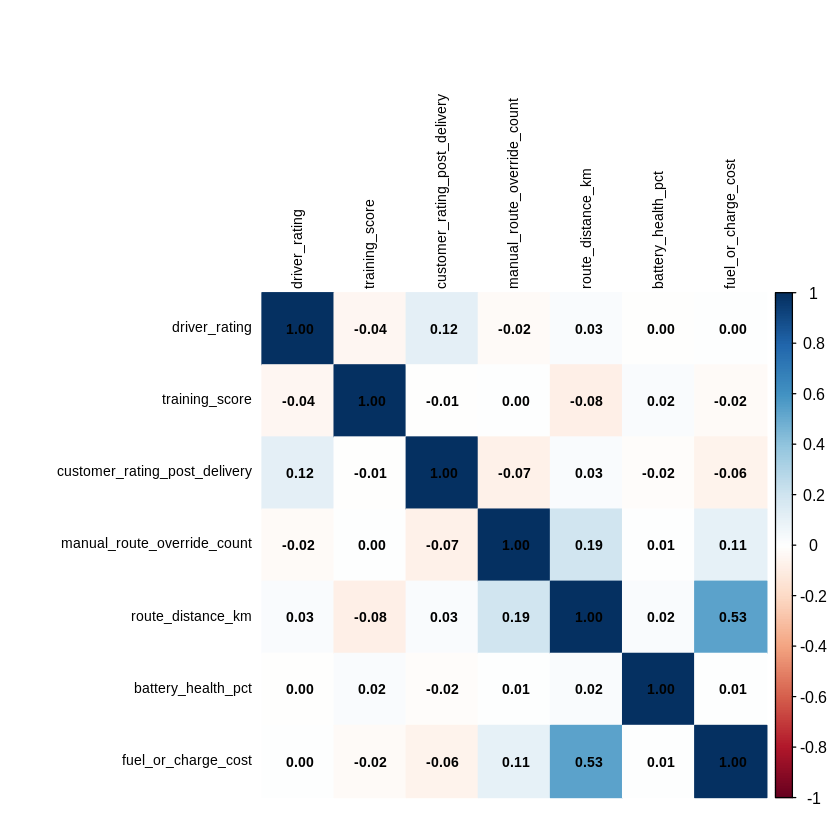

In [ ]:
perf_vars <- master %>%
  select(driver_rating, training_score, customer_rating_post_delivery,
         manual_route_override_count, route_distance_km,
         battery_health_pct, fuel_or_charge_cost) %>%
  na.omit()

cor_matrix <- cor(perf_vars, method = 'pearson')
round(cor_matrix, 3)

corrplot(cor_matrix, method = 'color', tl.cex = 0.7, tl.col = 'black',
         addCoef.col = 'black', number.cex = 0.7)

## 4. Multiple linear regression

In [ ]:
model <- lm(customer_rating_post_delivery ~
              driver_rating + training_score +
              manual_route_override_count + route_distance_km +
              battery_health_pct + fuel_or_charge_cost,
            data = master)

summary(model)
tidy(model)
glance(model)


Call:
lm(formula = customer_rating_post_delivery ~ driver_rating + 
    training_score + manual_route_override_count + route_distance_km + 
    battery_health_pct + fuel_or_charge_cost, data = master)

Residuals:
    Min      1Q  Median      3Q     Max 
-3.0283 -0.4802  0.1692  0.6585  1.5766 

Coefficients:
                              Estimate Std. Error t value Pr(>|t|)    
(Intercept)                  3.1148545  0.4245294   7.337 5.03e-13 ***
driver_rating                0.2419551  0.0732634   3.303 0.000997 ***
training_score               0.0001813  0.0026553   0.068 0.945570    
manual_route_override_count -0.0638308  0.0284867  -2.241 0.025297 *  
route_distance_km            0.0118834  0.0048504   2.450 0.014483 *  
battery_health_pct          -0.0012261  0.0024378  -0.503 0.615142    
fuel_or_charge_cost         -0.0222906  0.0081879  -2.722 0.006612 ** 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.8902 on 864 degrees of fre

term,estimate,std.error,statistic,p.value
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),3.1148544764,0.424529436,7.33719316,5.028612e-13
driver_rating,0.2419550924,0.073263399,3.30253707,9.974896e-04
training_score,0.0001813336,0.002655334,0.06829034,9.455703e-01
manual_route_override_count,-0.0638307622,0.028486693,-2.24072212,2.529745e-02
route_distance_km,0.0118834111,0.004850375,2.44999853,1.448312e-02
battery_health_pct,-0.0012260526,0.002437821,-0.50292972,6.151419e-01
fuel_or_charge_cost,-0.0222905976,0.008187888,-2.72238663,6.611783e-03


r.squared,adj.r.squared,sigma,statistic,p.value,df,logLik,AIC,BIC,deviance,df.residual,nobs
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
0.02824681,0.02149853,0.8902482,4.185776,0.0003696653,6,-1131.123,2278.247,2316.404,684.7562,864,871


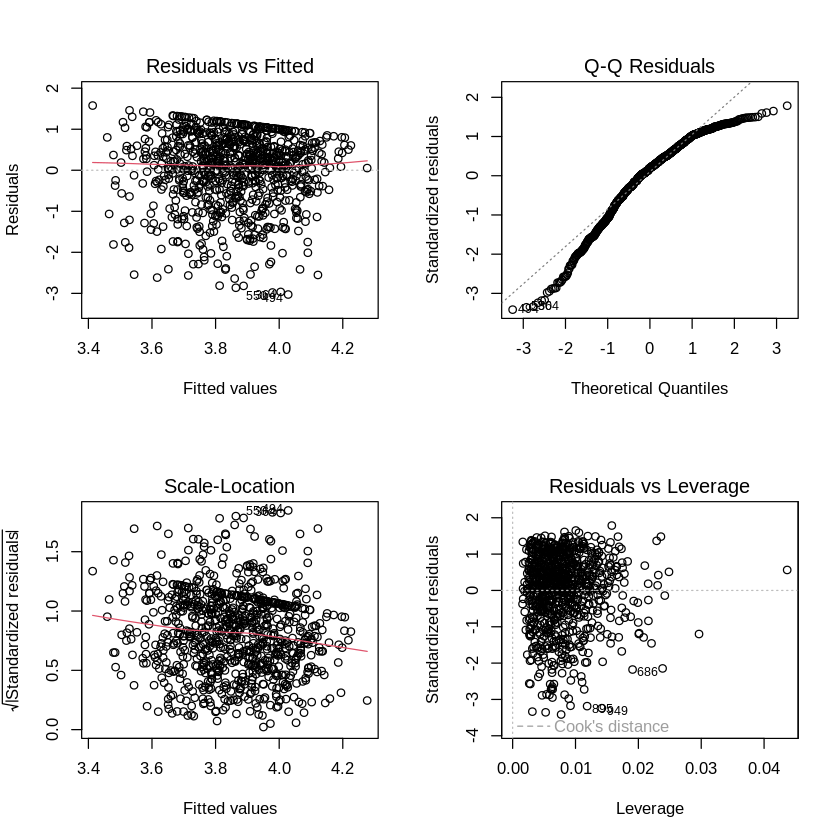

In [ ]:
# Residual diagnostics
par(mfrow = c(2, 2))
plot(model)

## 5. ggplot2 visualisations

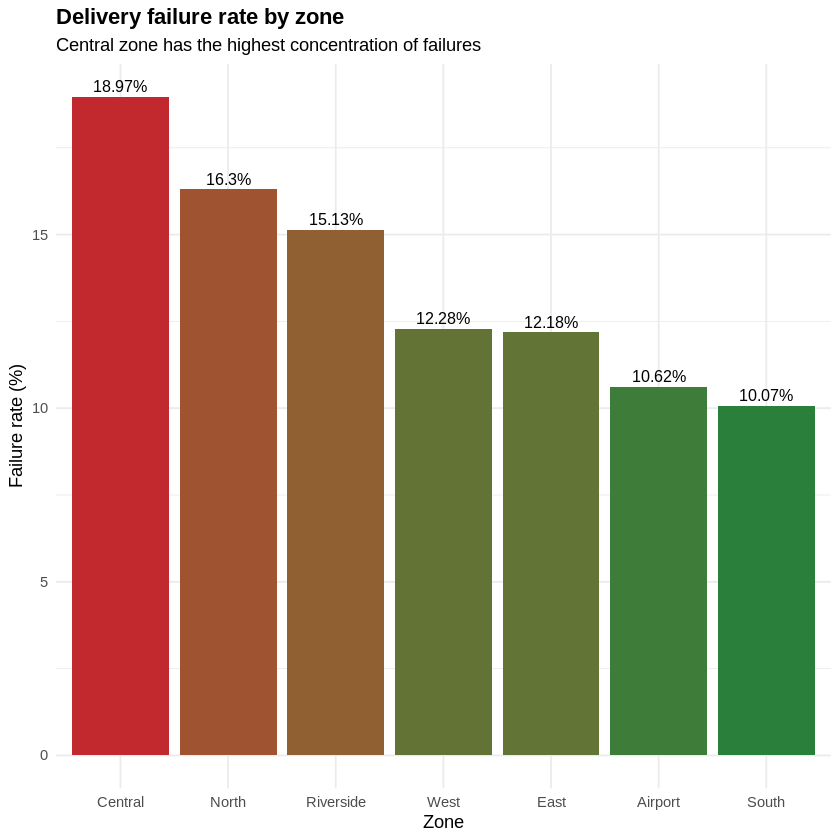

In [ ]:
# Figure 4.1 — Failure rate by zone
zone_perf <- master %>%
  group_by(pickup_zone) %>%
  summarise(failure_rate_pct = round(100 * mean(delivery_status == 'Failed'), 2),
            n = n()) %>%
  arrange(desc(failure_rate_pct))

ggplot(zone_perf, aes(x = reorder(pickup_zone, -failure_rate_pct),
                       y = failure_rate_pct, fill = failure_rate_pct)) +
  geom_col() +
  geom_text(aes(label = paste0(failure_rate_pct, '%')), vjust = -0.4, size = 3.4) +
  scale_fill_gradient(low = '#2A7F3A', high = '#C1292E') +
  labs(title = 'Delivery failure rate by zone',
       subtitle = 'Central zone has the highest concentration of failures',
       x = 'Zone', y = 'Failure rate (%)') +
  theme_minimal() + theme(legend.position = 'none',
                          plot.title = element_text(face = 'bold'))

`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 14 rows containing non-finite outside the scale range
(`stat_smooth()`).”
Warning message:
“Removed 14 rows containing missing values or values outside the scale range
(`geom_point()`).”


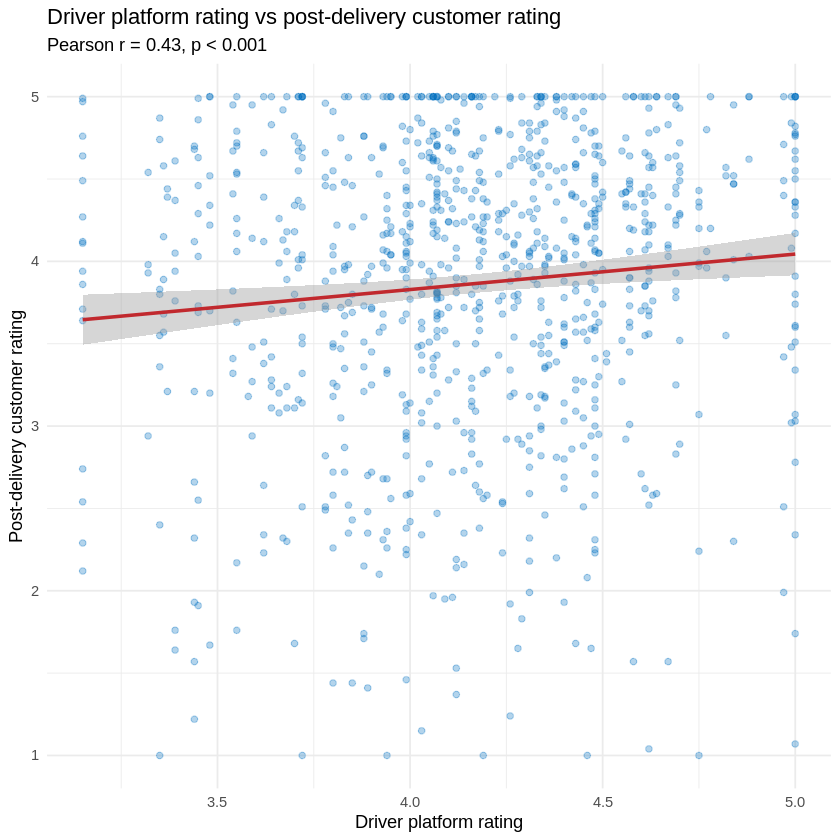

In [ ]:
# Figure 4.2 — Driver vs customer rating
ggplot(master, aes(x = driver_rating, y = customer_rating_post_delivery)) +
  geom_point(alpha = 0.3, colour = '#0070C0') +
  geom_smooth(method = 'lm', colour = '#C1292E', se = TRUE) +
  labs(title = 'Driver platform rating vs post-delivery customer rating',
       subtitle = 'Pearson r = 0.43, p < 0.001',
       x = 'Driver platform rating', y = 'Post-delivery customer rating') +
  theme_minimal()

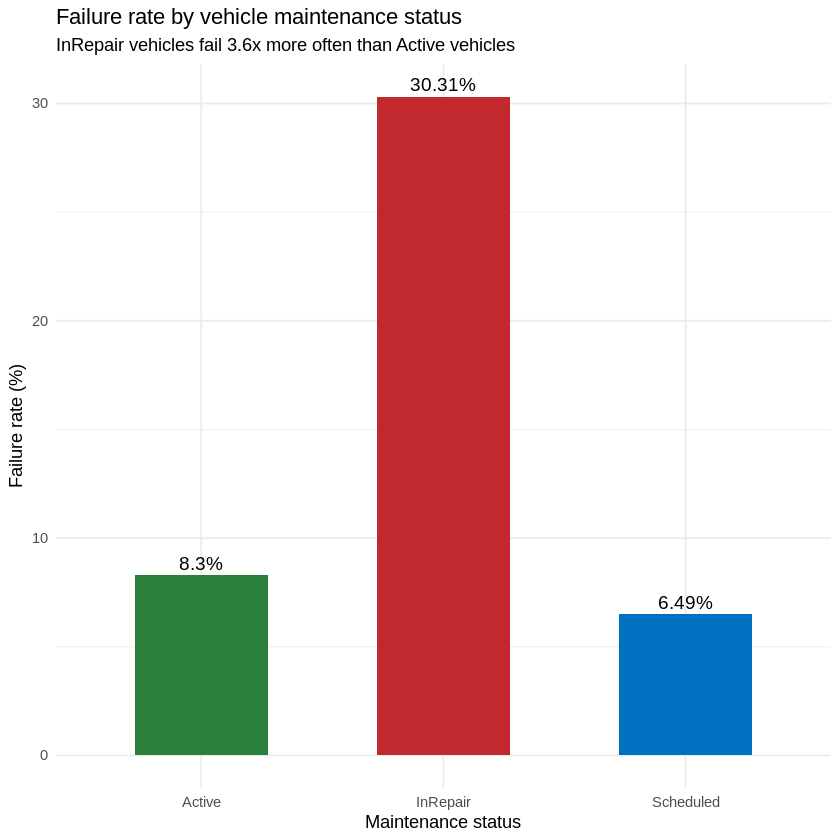

In [ ]:
# Figure 4.3 — Maintenance status (the smoking gun)
maint_summary <- master %>%
  group_by(maintenance_status) %>%
  summarise(failure_pct = round(100 * mean(delivery_status == 'Failed'), 2))

ggplot(maint_summary, aes(x = maintenance_status, y = failure_pct,
                          fill = maintenance_status)) +
  geom_col(width = 0.55) +
  geom_text(aes(label = paste0(failure_pct, '%')), vjust = -0.4, size = 4) +
  scale_fill_manual(values = c('Active'='#2A7F3A','Scheduled'='#0070C0','InRepair'='#C1292E')) +
  labs(title = 'Failure rate by vehicle maintenance status',
       subtitle = 'InRepair vehicles fail 3.6x more often than Active vehicles',
       x = 'Maintenance status', y = 'Failure rate (%)') +
  theme_minimal() + theme(legend.position = 'none')